### Image Classification using Transfer Learning

**Dataset:** Oxford-IIIT Pet

**Pretrained Model:** ResNet18

**Transfer Learning Techniques:**
- Feature Extraction
- Fine-Tuning

**Objective:**
Compare Feature Extraction and Fine-Tuning using a pretrained ResNet18 model on the Oxford-IIIT Pet dataset.

In [1]:
import torch #pytorch is the main deep learning library
import torchvision #it is a library specially made for computer vision

from torchvision import datasets #to download and load image datasets
from torchvision import transforms #we need to transform images to format that model can use because cnns cant understand jpegs or pngs
from torchvision import models # to use pretrained models
from torch.utils.data import DataLoader #it will make batches of data so that we can feed it to the model

import torch.nn as nn #nn contains the neural network and loss functions 
import torch.optim as optim #optim is we can say optimizer which make the model learn from the data
import matplotlib.pyplot as plt #to plot the images and graphs 
import numpy as np


from sklearn.metrics import(
        confusion_matrix,               #which classes are being confused with each other
        classification_report,          #how well the model is performing in each class
        accuracy_score                  #to measure the prediction accuracy of the model
)

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

PyTorch Version: 2.11.0+cu128
Torchvision Version: 0.26.0+cu128


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device using: ", device)
# this code is used to use gpu if available otherwise it will cpu now we have gpu nvidia cuda 
# so we are using cuda

device using:  cuda


In [3]:
print("PyTorch Version :", torch.__version__)
print("CUDA Available  :", torch.cuda.is_available())
print("CUDA Version    :", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU Name        :", torch.cuda.get_device_name(0))

PyTorch Version : 2.11.0+cu128
CUDA Available  : True
CUDA Version    : 12.8
GPU Name        : NVIDIA GeForce RTX 3050 6GB Laptop GPU


Oxford-IIIT Pet Dataset 

I chose this dataset because according to chatGPT this project had the potential to make me understand most of the basics and understanding for the CNN projects. this is one of the best dataset to work on as beginner as you get to learn many of the things.

In [4]:
#now we gonna download the dataset 
train_dataset = datasets.OxfordIIITPet(
        root = "../data", #this is the path where the dataset will be downloaded because lets keep it organised
        split = "trainval", #we want the trainig and validation data
        target_types = "category", #we want the category of the image
        download = True
)

In [5]:
image ,label = train_dataset[0] #this is to check the first image and its label
print(type(image))
print(type(label))

<class 'PIL.Image.Image'>
<class 'int'>


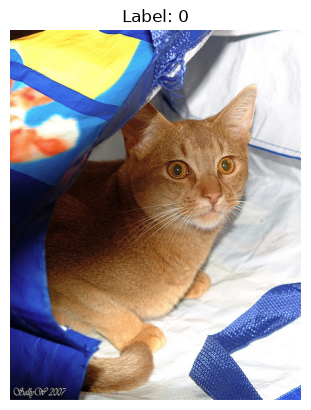

In [6]:
plt.imshow(image) #this is to show the image
plt.title(f"Label: {label}") #this is to show the label of the image
plt.axis("off") #this is to remove the axis from the image
plt.show() #this is to show the image

In [7]:
print("classes: " , train_dataset.classes) #this is to show the classes of the dataset

classes:  ['Abyssinian', 'American Bulldog', 'American Pit Bull Terrier', 'Basset Hound', 'Beagle', 'Bengal', 'Birman', 'Bombay', 'Boxer', 'British Shorthair', 'Chihuahua', 'Egyptian Mau', 'English Cocker Spaniel', 'English Setter', 'German Shorthaired', 'Great Pyrenees', 'Havanese', 'Japanese Chin', 'Keeshond', 'Leonberger', 'Maine Coon', 'Miniature Pinscher', 'Newfoundland', 'Persian', 'Pomeranian', 'Pug', 'Ragdoll', 'Russian Blue', 'Saint Bernard', 'Samoyed', 'Scottish Terrier', 'Shiba Inu', 'Siamese', 'Sphynx', 'Staffordshire Bull Terrier', 'Wheaten Terrier', 'Yorkshire Terrier']


In [8]:
#now we also want to know number of classes and the number of training images,
print("number of classes: ", len(train_dataset.classes)) #this is to show the number of classes
print("number of images: ", len(train_dataset)) #this is to show the number of images

number of classes:  37
number of images:  3680


In [9]:
# now we gonna inspect the image to get info for preprocessing the image for the model because,
#  we need to resize the image to 224x224 and also we need to normalize the image because the model is trained on normalized images so we need to normalize the images as well.
print("type of image: ", type(image))
print("type of label: ", type(label))
print("label: ", label),
print("breed or name of the class: ", train_dataset.classes[label]),
print("size of image: ", image.size)       

type of image:  <class 'PIL.Image.Image'>
type of label:  <class 'int'>
label:  0
breed or name of the class:  Abyssinian
size of image:  (394, 500)


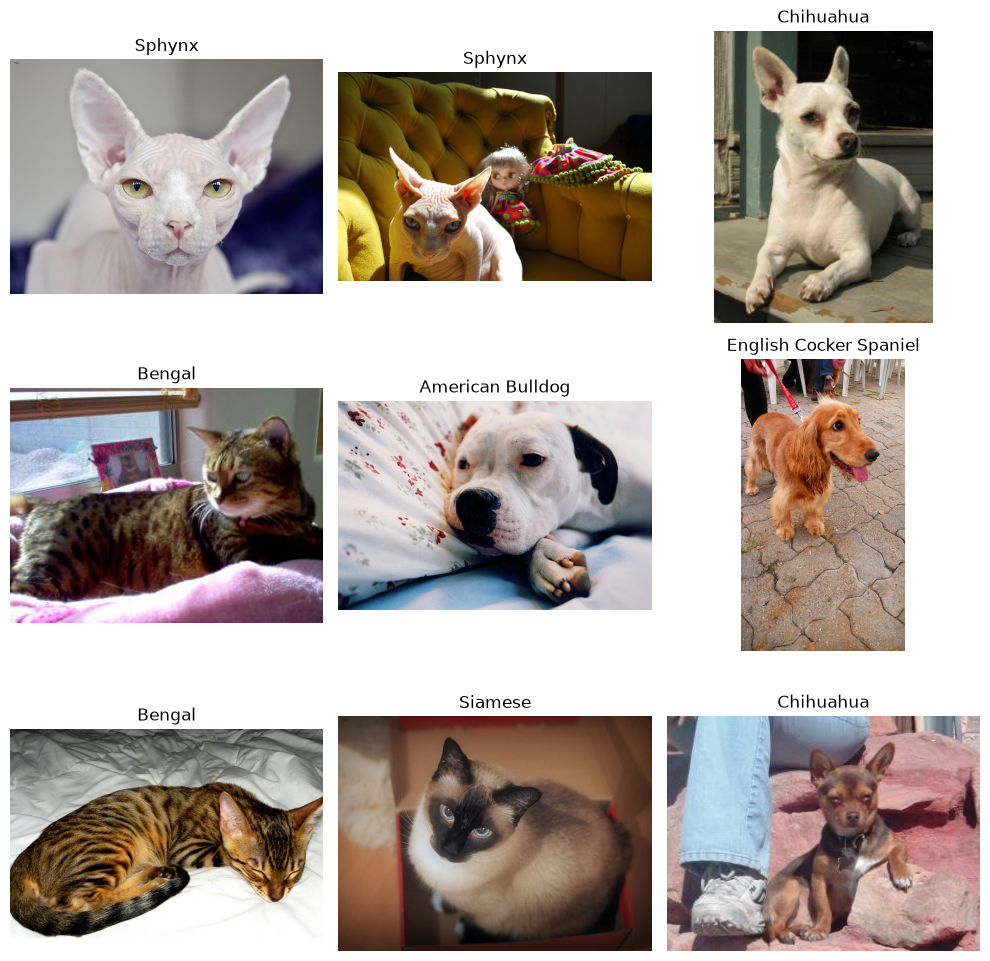

In [10]:
# we know before preprocessing the data we need to understand the data in raw so we can conclude from one image thats why now we will randomly chose 9 images from the 
# dataset which will help us to understand the data in raw form and then we will preprocess the data and then we will feed it to the model.
import random

plt.figure(figsize=(10,10))

for i in range(9):
    index = random.randint(0, len(train_dataset)-1)

    image, label = train_dataset[index]

    plt.subplot(3,3,i+1)
    plt.imshow(image)
    plt.title(train_dataset.classes[label])
    plt.axis("off")

plt.tight_layout()
plt.show()

so i made some observation in this fig. we see different breeds
1. most of them are facing camera which helps model extract more feature but we need to train model from different viewpoints
2. lightning the main cause of mistake see some picture of breed are in sunlight outside and some breeds are inside which is why we need to normalize the dataset
3. images are of different size so we need to reshape them because model cant process the images of different size.

In [11]:
#preprocessing here

# below is the preprocessing for the training dataset
train_transform = transforms.Compose([
    transforms.Resize((224, 224)), #resizing the image to 224x224 because the model is trained on 224x224 images
    transforms.RandomHorizontalFlip(p=0.5), #flipping the image horizontally with a probability of 0.5 because it will help the model to learn better
    transforms.ToTensor(), #converting the image to tensor because the model can only understand tensors
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ) #normalizing the image with the mean and standard deviation of the ImageNet dataset
])

# Preprocessing for Test Dataset
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])
#we dont flip in train because it will affect the accuracy of the prediction because everytime the image will be different but all we need is original image to make prediction
#we train model on flips just to make it robust and learn better but when we test we need to test on original image so we dont flip in test
#example trainer train driving student in rain, storm or may be on not well constructed road. bit during test he will not say wear blindfold then we will test you 
#instead based on real driving doesnt matter the rain or road.

In [17]:

train_dataset = datasets.OxfordIIITPet(
    root="../data",
    split="trainval",
    target_types="category",
    download=False,
    transform=train_transform
)

test_dataset = datasets.OxfordIIITPet(
    root="../data",
    split="test",
    target_types="category",
    download=False,
    transform=test_transform
)

In [18]:
image, label = train_dataset[0]

print("Image Shape:", image.shape)
print("Label:", label)
print("Breed:", train_dataset.classes[label])

Image Shape: torch.Size([3, 224, 224])
Label: 0
Breed: Abyssinian


In [19]:
train_loader = DataLoader(
        train_dataset,
        batch_size=32, #this is the number of images that will be fed to the model at once
        shuffle=True, #this is to shuffle the data so that the model can learn better
)
test_loader = DataLoader(
        test_dataset,
        batch_size=32, #this is the number of images that will be fed to the model at once
        shuffle=False, #this is false because we dont need to shuffle the test data because we are not training the model on test data
)

In [20]:
images, labels = next(iter(train_loader))

print("Images Shape:", images.shape)
print("Labels Shape:", labels.shape)

Images Shape: torch.Size([32, 3, 224, 224])
Labels Shape: torch.Size([32])


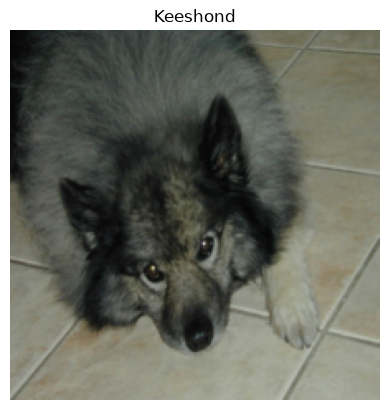

In [21]:
image = images[0].permute(1, 2, 0)

# Undo normalization for display
mean = torch.tensor([0.485, 0.456, 0.406])
std = torch.tensor([0.229, 0.224, 0.225])

image = image * std + mean
image = image.clamp(0, 1)

plt.imshow(image)
plt.title(train_dataset.classes[labels[0]])
plt.axis("off")
plt.show()

In [ ]:
# now we loading the pretrained resnet18 model from torchvision.models and we will use it for transfer learning.

model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print(model)

In [23]:
print(model.fc)

Linear(in_features=512, out_features=1000, bias=True)


In [24]:

model.fc = nn.Linear(
    in_features=model.fc.in_features,
    out_features=37
)

print(model.fc)

Linear(in_features=512, out_features=37, bias=True)


In [25]:
# Freeze all the pretrained layers
for param in model.parameters():
    param.requires_grad = False

In [26]:
# Train only the final classification layer
for param in model.fc.parameters():
    param.requires_grad = True

In [27]:
model = model.to(device)

In [28]:
criterion = nn.CrossEntropyLoss()

In [30]:
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

In [31]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print(f"Trainable Parameters: {trainable:,}")
print(f"Total Parameters: {total:,}")

Trainable Parameters: 18,981
Total Parameters: 11,195,493


In [32]:
epochs = 5

In [33]:
for epoch in range(epochs):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/5] | Loss: 1.9568 | Accuracy: 55.95%
Epoch [2/5] | Loss: 0.7506 | Accuracy: 84.97%
Epoch [3/5] | Loss: 0.5148 | Accuracy: 88.78%
Epoch [4/5] | Loss: 0.4119 | Accuracy: 90.49%
Epoch [5/5] | Loss: 0.3426 | Accuracy: 91.93%


In [34]:
model.eval()

correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 86.05%


In [35]:
from sklearn.metrics import classification_report

print(classification_report(
    all_labels,
    all_predictions,
    target_names=test_dataset.classes
))

                            precision    recall  f1-score   support

                Abyssinian       0.87      0.56      0.68        98
          American Bulldog       0.70      0.86      0.77       100
 American Pit Bull Terrier       0.79      0.34      0.48       100
              Basset Hound       0.85      0.94      0.89       100
                    Beagle       0.92      0.87      0.89       100
                    Bengal       0.50      0.99      0.66       100
                    Birman       0.65      0.85      0.74       100
                    Bombay       0.95      0.83      0.88        88
                     Boxer       0.89      0.87      0.88        99
         British Shorthair       0.94      0.77      0.85       100
                 Chihuahua       0.84      0.84      0.84       100
              Egyptian Mau       1.00      0.67      0.80        97
    English Cocker Spaniel       0.91      0.90      0.90       100
            English Setter       0.87      0.90

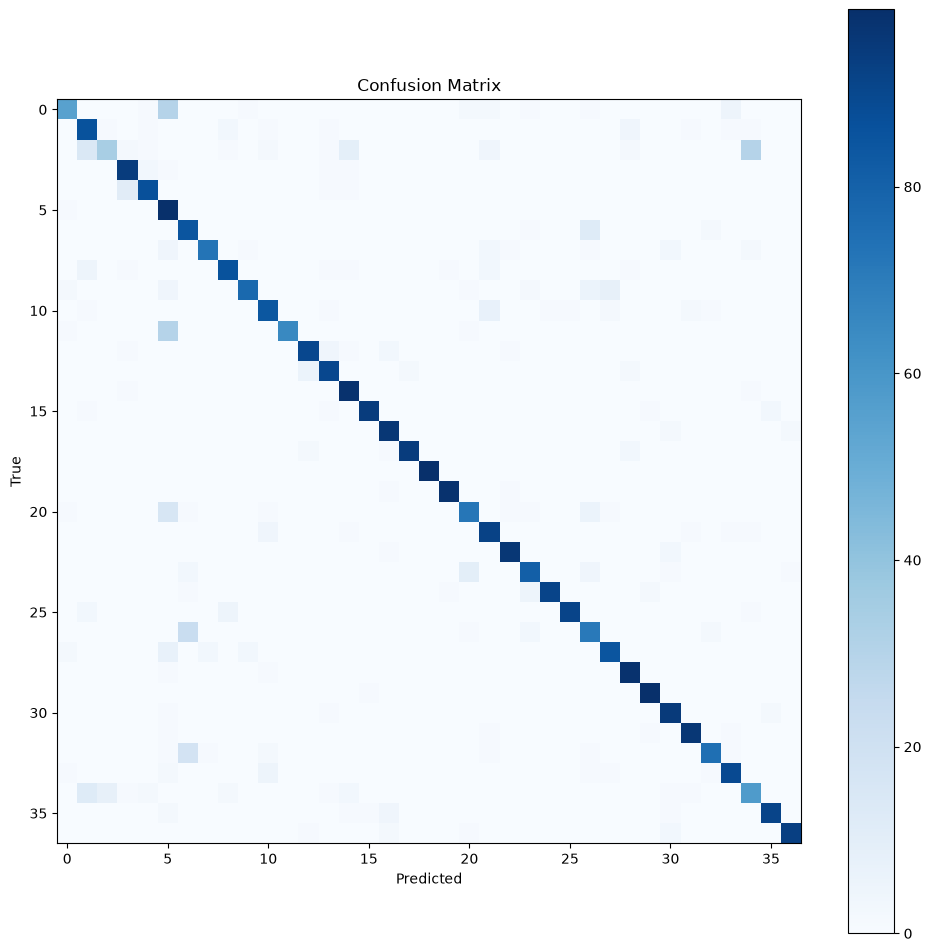

In [37]:

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(12,12))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

lets finetune the the model,

we unfreeze the last layer and make it learn at very low learning rate like 0.001 because if it learns too much it will forget what it learnt before. so learning a little 
will help model 


In [39]:
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

model_ft.fc = nn.Linear(
    model_ft.fc.in_features,
    37
)

In [40]:
for param in model_ft.parameters():
    param.requires_grad = False

In [41]:
for param in model_ft.layer4.parameters():
    param.requires_grad = True

for param in model_ft.fc.parameters():
    param.requires_grad = True

In [42]:
model_ft = model_ft.to(device)

In [43]:
criterion = nn.CrossEntropyLoss()

In [45]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model_ft.parameters()),
    lr=0.0001
)

In [46]:
trainable = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_ft.parameters())

print(f"Trainable Parameters: {trainable:,}")
print(f"Total Parameters: {total:,}")

Trainable Parameters: 8,412,709
Total Parameters: 11,195,493


In [54]:
epochs = 10

In [55]:
for epoch in range(epochs):

    model_ft.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model_ft(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = 100 * correct / total

    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Loss: {epoch_loss:.4f} | "
        f"Accuracy: {epoch_accuracy:.2f}%"
    )

Epoch [1/10] | Loss: 0.0540 | Accuracy: 99.78%
Epoch [2/10] | Loss: 0.0391 | Accuracy: 99.78%
Epoch [3/10] | Loss: 0.0263 | Accuracy: 99.92%
Epoch [4/10] | Loss: 0.0182 | Accuracy: 100.00%
Epoch [5/10] | Loss: 0.0138 | Accuracy: 99.97%
Epoch [6/10] | Loss: 0.0110 | Accuracy: 100.00%
Epoch [7/10] | Loss: 0.0089 | Accuracy: 100.00%
Epoch [8/10] | Loss: 0.0074 | Accuracy: 100.00%
Epoch [9/10] | Loss: 0.0061 | Accuracy: 100.00%
Epoch [10/10] | Loss: 0.0053 | Accuracy: 100.00%


In [56]:
model_ft.eval()

correct = 0
total = 0

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model_ft(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 88.55%


In [51]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=test_dataset.classes
    )
)

                            precision    recall  f1-score   support

                Abyssinian       0.86      0.81      0.83        98
          American Bulldog       0.69      0.86      0.77       100
 American Pit Bull Terrier       0.72      0.53      0.61       100
              Basset Hound       0.92      0.86      0.89       100
                    Beagle       0.85      0.90      0.87       100
                    Bengal       0.75      0.95      0.84       100
                    Birman       0.67      0.92      0.78       100
                    Bombay       0.87      0.95      0.91        88
                     Boxer       0.85      0.89      0.87        99
         British Shorthair       0.97      0.71      0.82       100
                 Chihuahua       0.87      0.81      0.84       100
              Egyptian Mau       0.91      0.89      0.90        97
    English Cocker Spaniel       0.96      0.82      0.89       100
            English Setter       0.86      0.95

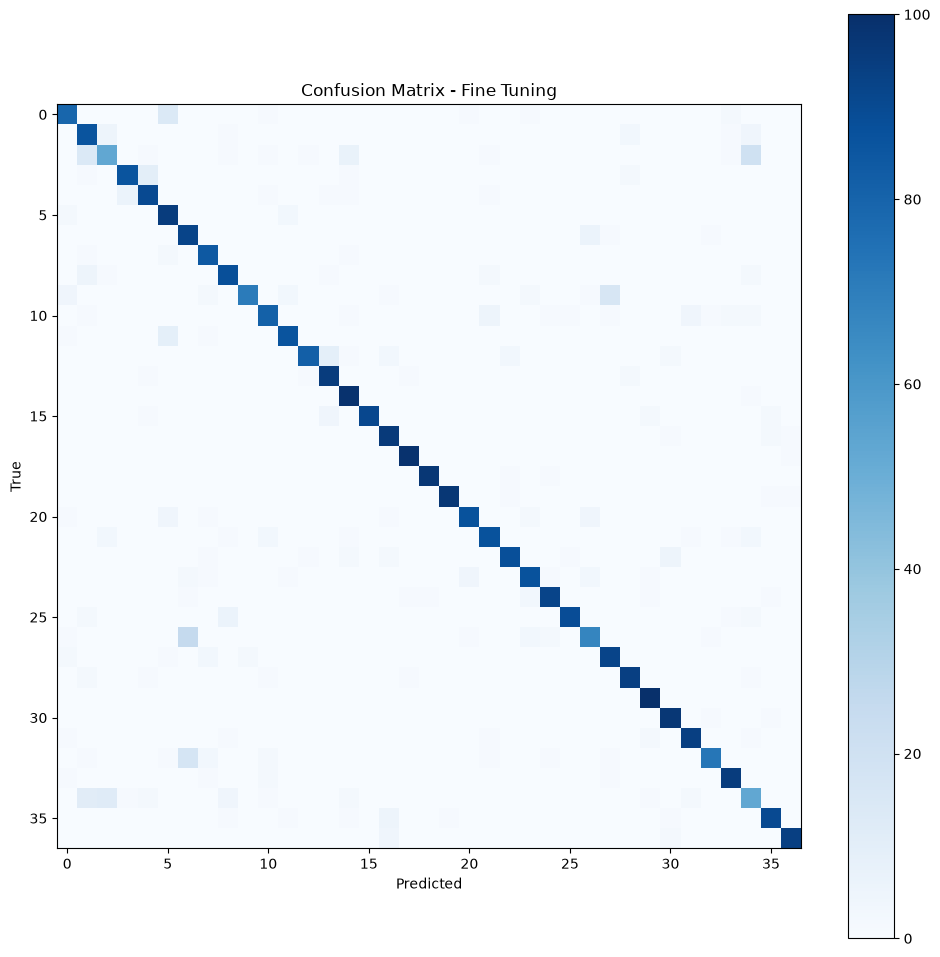

In [52]:

cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(12, 12))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Fine Tuning")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [53]:
torch.save(
    model_ft.state_dict(),
    "../models/resnet18_finetuned.pth"
)

print("Fine-Tuned Model Saved Successfully!")

Fine-Tuned Model Saved Successfully!


Question 1.

Why did you choose your specific model and dataset combination? What tradeoffs did you consider (speed,
accuracy, dataset size, number of classes)?

Answer

I choose ResNet18 because it is already pretrained on ImageNet dataset and it can learn image features very well. It also trains faster and needs less resources than bigger models. I choose Oxford-IIIT Pet Dataset because it has 37 cat and dog breeds which is good for image classification and transfer learning.

Question 2

Which strategy — feature extraction or fine-tuning — achieved higher validation accuracy for your setup?
What do you think explains the difference?

Answer

In my project, Fine-Tuning performed better than Feature Extraction.
Feature Extraction test accuracy = 86.05%
Fine-Tuning test accuracy = 88.55%
Fine-Tuning gave better accuracy because it trains the last ResNet layer with the final classifier. This helps the model learn more about my dataset and improve the prediction.

Question 3

What would likely happen if you used the same learning rate for both the head and the backbone during finetuning? Why?

Answer

If same learning rate is used, the pretrained layers can change too much and forget the knowledge learned from ImageNet. So it is better to use a smaller learning rate for pretrained layers and a higher learning rate for the new classification layer.

Question 4

Which classes were most often confused with each other in your confusion matrix? Suggest a reason why.

Answer

Some pet breeds were confused because they look very similar. Their fur colour, face shape and ears are almost same. Different background, lighting and image angle also make prediction difficult.

Question 5

If you had a new dataset with only 200 labelled images total, would you choose feature extraction or finetuning? Justify your answer.

Answer 

I will choose Feature Extraction because with only 200 images the model can overfit if many layers are trained. Feature Extraction only trains the last layer, so it works better with small datasets.


## model accuracy comparison

 Feature Extraction =    Train accuracy->       91.93%               test accuracy ->   86.05% 

 Fine-Tuning   =     Train accuracy->           99.54%               test accuracy ->   88.55% 


## Learning rate explanation

A smaller learning rate is used for the pretrained backbone because it already contains useful learned features from ImageNet. A higher learning rate is used for the new classification layer because it starts with random weights and needs to learn faster.

## Conclusion

In this project, Transfer Learning was performed using a pretrained ResNet18 model on the Oxford-IIIT Pet dataset. i used to 2 approaches , 1.feature extraction 2.fine tuning
got accuracy about 86.05% and 88.55% respectively.This demonstrates that Fine-Tuning can better adapt pretrained features to a specific task, resulting in improved classification performance.